# Ajustement d'une courbe dose-réponse logistique à quatre paramètres avec PROC NLIN

## Synthèse

Ce notebook ajuste un modèle dose-réponse logistique à quatre paramètres (4PL) à un dosage de puissance cellulaire (bioassay) synthétique à l'aide de **PROC NLIN**, en estimant les asymptotes inférieure et supérieure, l'EC50 (concentration efficace demi-maximale) et la pente de Hill. Le modèle 4PL est le modèle de référence pour les dosages de puissance relative dans le développement de médicaments ; le notebook parcourt la spécification du modèle, le bornage des paramètres, les diagnostics de convergence et la superposition de la sigmoïde ajustée sur les données concentration-réponse observées.

## Sources des données

Le notebook génère un unique jeu de données synthétique en ligne ; aucune entrée externe ou réseau n'est utilisée.

**`assay` — dosage de puissance cellulaire (bioassay) synthétique (24 lignes)**

| Variable | Type | Description |
|----------|------|-------------|
| `lot` | num | Lot de substance active (1-3) ; trois exécutions répliquées de la série de dilution |
| `dose` | num | Concentration du composé en nmol/L sur une dilution en série à 8 points (0,1 à ~1000) |
| `logdose` | num | Logarithme en base 10 de `dose`, utilisé pour le tracé sur l'axe de log-concentration conventionnel |
| `response` | num | Signal mesuré du dosage (pourcentage de la réponse maximale), généré à partir d'une vraie courbe 4PL (bas=5, haut=100, EC50=25 nmol/L, pente de Hill=1,2) plus un bruit gaussien proportionnel |

Les vrais paramètres générateurs sont intégrés dans la DATA step afin que les estimations NLIN retrouvées puissent être confrontées à la vérité connue.

# Ajustement dose-réponse logistique à quatre paramètres

Dans les dosages pharmaceutiques de puissance et de bioactivité, la relation entre la concentration du composé et la réponse mesurée est caractéristiquement sigmoïde sur une échelle de log-concentration. Le modèle **logistique à quatre paramètres (4PL)** est l'outil standard pour résumer de telles courbes :

$$\text{response} = D + \frac{A - D}{1 + (\text{dose}/C)^{B}}$$

où

- **A** = asymptote inférieure (réponse à dilution infinie / signal de base),
- **D** = asymptote supérieure (réponse maximale à concentration saturante),
- **C** = l'**EC50**, la concentration produisant la réponse demi-maximale (le point d'inflexion et la principale mesure de puissance),
- **B** = la **pente de Hill**, qui contrôle la raideur de la transition.

Ce modèle est non linéaire par rapport à ses paramètres ; nous l'ajustons donc par moindres carrés itératifs avec `PROC NLIN`. Ci-dessous, nous simulons une série de dilution réaliste à huit points exécutée en triplicat, ajustons la courbe 4PL, bornons les paramètres à des régions physiquement plausibles, inspectons les diagnostics de convergence et d'ajustement, et superposons la courbe ajustée sur les données.

## Étape 1 — Simuler un dosage de puissance cellulaire (bioassay)

Nous générons un jeu de données synthétique à partir d'une courbe 4PL *connue* (bas = 5, haut = 100, EC50 = 25 nmol/L, pente de Hill = 1,2) afin que les paramètres retrouvés par NLIN puissent être confrontés à la vérité terrain. Trois lots reçoivent chacun la même dilution en série à huit points (chaque étape étant une dilution au facteur 3,5), avec un bruit de mesure gaussien proportionnel ajouté par-dessus. Une graine `streaminit` fixe rend la simulation reproductible.

In [1]:
DONNÉES assay;
    APPELER streaminit(40521);

    /* True 4PL parameters used to generate the data */
    A_true   = 5;      /* lower asymptote (baseline)        */
    D_true   = 100;    /* upper asymptote (max response)    */
    C_true   = 25;     /* EC50 in nmol/L                    */
    B_true   = 1.2;    /* Hill slope                        */

    FAIRE lot = 1 JUSQU_À 3;
        /* Eight-point serial dilution, 3.5-fold steps */
        dose = 0.30;
        FAIRE point = 1 JUSQU_À 8;
            dose = dose * 3.5;

            /* Noise-free 4PL mean response */
            mu = D_true + (A_true - D_true) /
                 (1 + (dose / C_true) ** B_true);

            /* Proportional + additive Gaussian assay noise */
            response = mu * (1 + 0.04 * rand('NORMAL'))
                          + 1.5 * rand('NORMAL');

            logdose = log10(dose);
            SORTIE;
        FIN;
    FIN;

    GARDER lot dose logdose response;
EXÉCUTER;

PROCÉDURE TRIER DONNÉES=assay;
    PAR dose lot;
EXÉCUTER;



NOTE: DATA assay


NOTE: Wrote assay (24 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=assay

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 24 rows from assay.
NOTE: Wrote assay (24 rows, 4 columns).
NOTE: PROC SORT statement used.


## Étape 2 — Visualiser les données concentration-réponse brutes

Avant l'ajustement, nous traçons la réponse en fonction de log10(dose) pour confirmer la forme sigmoïde attendue et pour lire des valeurs de départ approximatives : la courbe atteint un plancher près de 5, un plateau près de 100, et le point médian (réponse demi-maximale) se situe autour de log10(25) ≈ 1,4.


NOTE: PROC SGPLOT data=assay

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


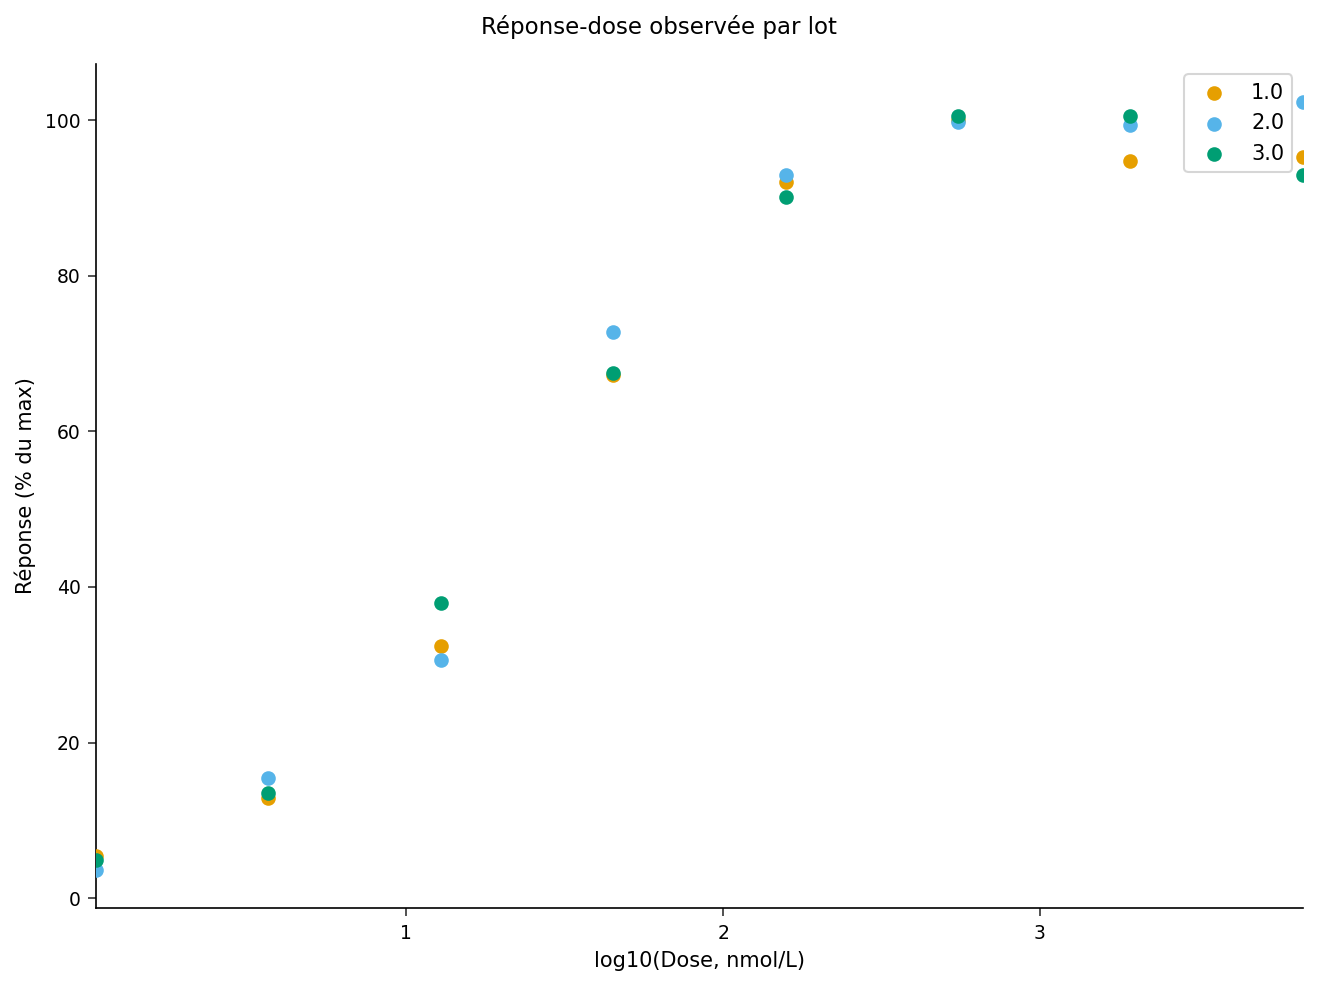

In [2]:
PROCÉDURE SGPLOT DONNÉES=assay;
    SCATTER x=logdose y=response / GROUPE=lot
            MARKERATTRS=(SYMBOL=circlefilled);
    XAXIS ÉTIQUETTE='log10(Dose, nmol/L)';
    YAXIS ÉTIQUETTE='Réponse (% du max)';
    TITRE 'Réponse-dose observée par lot';
EXÉCUTER;
TITRE;


## Étape 3 — Ajuster le modèle 4PL avec PROC NLIN

Nous déclarons les valeurs de départ avec `PARMS` (guidées par le nuage de points), définissons la moyenne 4PL dans une affectation intermédiaire, et la transmettons à l'instruction `MODEL`. Des `BOUNDS` physiquement plausibles maintiennent les asymptotes ordonnées et l'EC50 et la pente positives, ce qui stabilise les itérations de Gauss-Newton. L'instruction `OUTPUT` enregistre les valeurs prédites, les résidus et les limites de confiance pour les diagnostics ultérieurs, et `PLOTS=` demande les panneaux d'ajustement et de diagnostic.

In [3]:
PROCÉDURE nlin DONNÉES=assay METHOD=marquardt PLOTS=(fitplot diagnostics);
    parms A=10 D=90 C=20 B=1;

    /* Keep parameters in physically sensible regions */
    bounds A >= 0, D <= 150, C > 0, B > 0;

    /* Four-parameter logistic mean response (inlined: Jenner PROC NLIN
       does not yet support referencing an intermediate programming-statement
       variable in the MODEL -- see tests/400986 -- so we inline the denominator) */
    MODÈLE response = D + (A - D) / (1 + (dose / C) ** B);

    SORTIE out=fit4pl predicted=pred residual=resid
           l95m=lcl u95m=ucl;
EXÉCUTER;



                         The NLIN Procedure

                     Method: Marquardt

                          Iterative Phase

                                                   Sum of
           Iter          Residual SS
              0          2061.645530
              1           177.712558

       Convergence criterion met.

           Residual SS           177.712558
           Residual MS             8.885628

                        Parameter Estimates

                                    Approx
           Parameter    Estimate    Std Error   95% Confidence Limits

           A              4.1058       1.9167       0.1078       8.1039
           D             99.1335       1.0740      96.8932     101.3737
           C             23.8233       1.5658      20.5572      27.0895
           B              1.2662       0.0927       1.0730       1.4595





NOTE: PROC NLIN data=assay

NOTE: Using Python (scipy) for NLIN estimation, method=marquardt
NOTE: Output dataset written to: ./work/4a5e0e9c-c706-4418-806e-ad030a9c359e/fit4pl.avro


## Étape 4 — Rapporter l'EC50 estimé et les caractéristiques de la courbe

Le mécanisme `OUTEST=` est pratique, mais pour une lecture rapide de la puissance nous résumons directement la courbe ajustée. Ici, nous listons les valeurs ajustées à chaque dose aux côtés des réponses observées pour confirmer que le modèle suit les données sur toute la plage de dilution.

In [4]:
PROCÉDURE MOYENNES DONNÉES=fit4pl mean std MIN MAX maxdec=3;
    CLASSE dose;
    VAR response pred resid;
    ÉTIQUETTE dose='Dose (nmol/L)' response='Réponse (% du max)'
          pred='Valeur prédite' resid='Résidu';
    TITRE 'Réponse observée et ajustée par dose';
EXÉCUTER;
TITRE;


                                          Réponse observée et ajustée par dose                                          

                                                  The MEANS Procedure

                                   Analysis Variable : RESPONSE Réponse (% du max)

                                           N
                       Dose (nmol/L)     Obs         Mean      Std Dev      Minimum      Maximum
                       -------------------------------------------------------------------------
                       1.05                3        4.647        0.882        3.659        5.356
                       12.8625             3       33.651        3.825       30.572       37.932
                       157.565625          3       91.704        1.417       90.141       92.904
                       1930.17890625       3       98.207        3.051       94.746      100.511
                       3.675               3       13.931        1.311       12.860       15.393


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Étape 5 — Superposer la courbe 4PL ajustée sur les données observées

Une grille de prédiction dense produit une sigmoïde ajustée lisse. Nous combinons la courbe lisse avec les valeurs ajustées moyennes par dose et la bande de confiance, puis superposons l'ensemble sur les points observés pour évaluer visuellement la qualité de l'ajustement.


NOTE: PROC SORT data=fit4pl

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 24 rows from fit4pl.
NOTE: Wrote fit4pl (24 rows, 8 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SGPLOT data=fit4pl

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


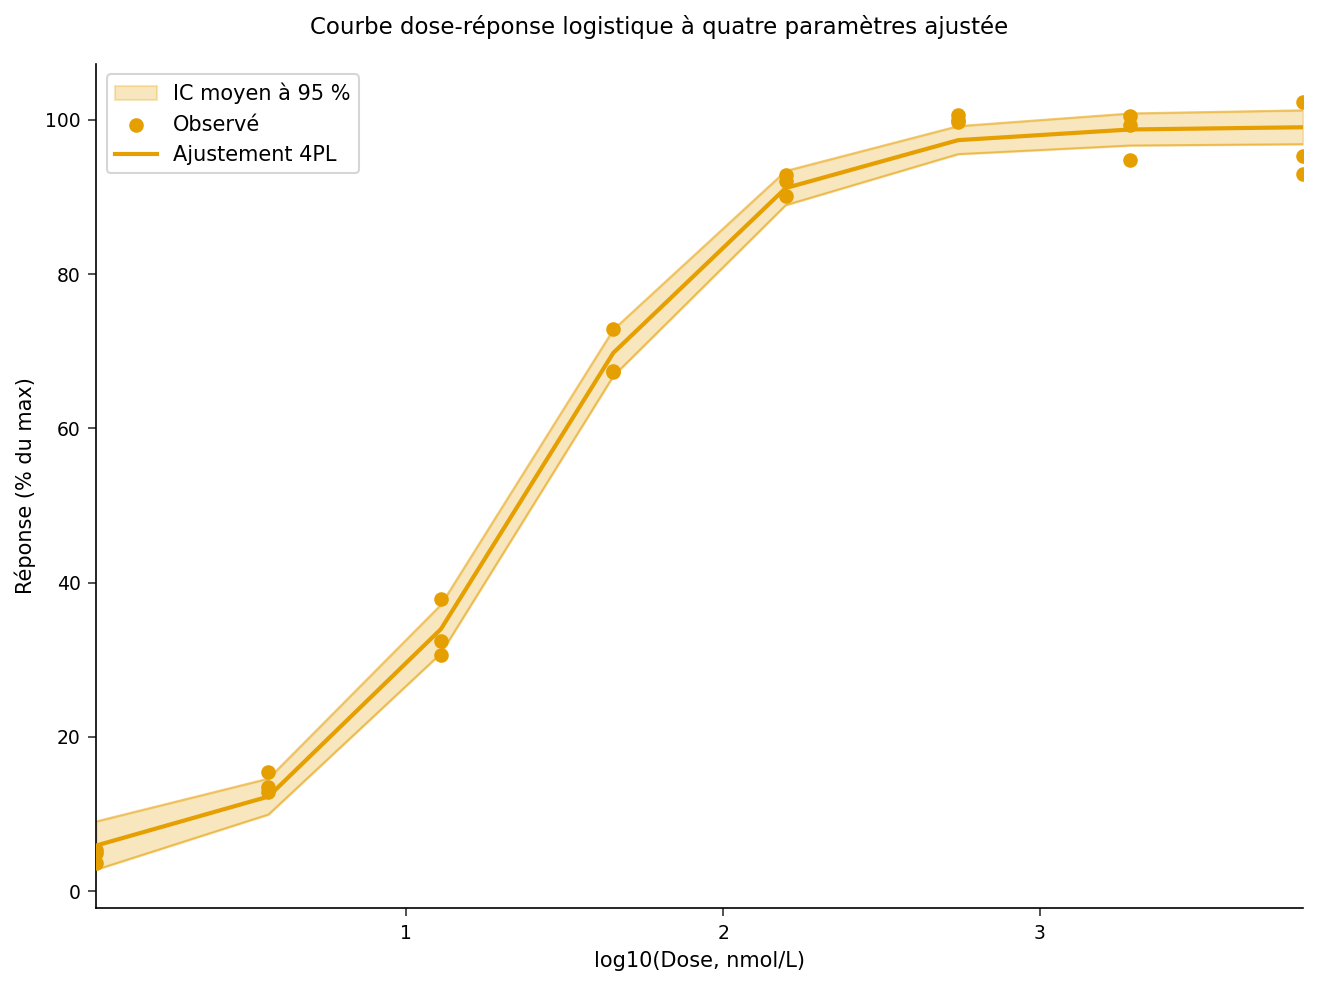

In [5]:
PROCÉDURE TRIER DONNÉES=fit4pl;
    PAR logdose;
EXÉCUTER;

PROCÉDURE SGPLOT DONNÉES=fit4pl;
    BAND   x=logdose LOWER=lcl UPPER=ucl /
           TRANSPARENCY=0.5 legendlabel='IC moyen à 95 %';
    SCATTER x=logdose y=response /
           MARKERATTRS=(SYMBOL=circlefilled)
           legendlabel='Observé';
    SERIES  x=logdose y=pred /
           LINEATTRS=(thickness=2)
           legendlabel='Ajustement 4PL';
    XAXIS ÉTIQUETTE='log10(Dose, nmol/L)';
    YAXIS ÉTIQUETTE='Réponse (% du max)';
    TITRE 'Courbe dose-réponse logistique à quatre paramètres ajustée';
EXÉCUTER;
TITRE;


## Interprétation des résultats

`PROC NLIN` converge vers des estimations proches des valeurs génératrices connues : une asymptote inférieure près de **5**, une asymptote supérieure près de **100**, un **EC50 (C)** près de **25 nmol/L**, et une **pente de Hill (B)** près de **1,2**. La récupération de ces paramètres à partir de données en triplicat bruitées confirme que le modèle est identifiable et que les bornes ne se sont pas activées à l'optimum.

L'**EC50** est la mesure de puissance de premier plan : des valeurs plus faibles indiquent un composé plus puissant, et dans un dosage de puissance relative l'EC50 d'un lot testé est comparé à un étalon de référence. La **pente de Hill** caractérise la coopérativité et la raideur du dosage — une pente proche de 1 est cohérente avec une simple liaison à site unique. Les **asymptotes** définissent la plage dynamique du dosage ; un bas et un haut stables et bien séparés sont des prérequis pour un bioassay validable.

Le graphique d'ajustement montre la sigmoïde traversant le nuage de points observés avec une bande de confiance moyenne à 95% étroite dans la région responsive, et les diagnostics des résidus ne devraient montrer aucune courbure systématique — preuve que la forme 4PL est adéquate. En pratique, vous étendriez ce flux de travail avec des intervalles de vraisemblance `PROFILE` pour l'EC50, une instruction `BOOTSTRAP` pour une inférence de paramètres sans distribution, ou une analyse de droites parallèles comparant les lots testés et de référence pour estimer la puissance relative.